<a href="https://colab.research.google.com/github/ivanriuk/Tarea4_Optimizacion2/blob/main/Heuristic2_closterANDgreedy.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Instance reading
Each instance is a .txt file that has the following structure:

type  vehicle_number  costumer_number  depor_number


---


After we define the capacity of each vehicle:

max_route  max_load


---


Then the customer info. Here its just necesarry data in column 2, 3 and 5 that corresponds to:

x_position  y_position  weight


---


Finally we gather the depot information in columns 2 and 3:

depot_x  depot_y

# Instances are uploaded to the folder "/content/instances"

In [419]:
using Plots

In [420]:
function read_mdvrp_instance(filepath::String)
    # Convertir cada línea en vector de enteros
    data = [parse.(Float64, split(fila)) for fila in readlines(filepath)]

    # =========================
    # Primera fila
    # =========================
    first_row = data[1]
    type       = Int(first_row[1])
    truck_num  = Int(first_row[2])
    client_num = Int(first_row[3])
    depot_num  = Int(first_row[4])

    # =========================
    # Filas de capacidades
    # =========================
    cap_start = 2
    cap_end   = 1 + depot_num

    capacities = [data[i][2] for i in cap_start:cap_end]

    # =========================
    # Filas de clientes
    # =========================
    client_start = cap_end + 1
    client_end   = client_start + client_num - 1

    index     = Vector{Int}(undef, client_num)
    positions = Matrix{Float64}(undef, client_num, 2)
    weights   = Vector{Float64}(undef, client_num)

    for (j, i) in enumerate(client_start:client_end)
        row = data[i]
        index[j]        = Int(row[1])   #indice
        positions[j, 1] = row[2]   # x
        positions[j, 2] = row[3]   # y
        weights[j]      = row[5]   # weight
    end

    #clients = hcat(index, positions, weights)

    # =========================
    # Filas de depósitos
    # =========================
    depot_start = client_end + 1
    depot_end   = depot_start + depot_num - 1

    depots = Matrix{Float64}(undef, depot_num, 3)

    for (j, i) in enumerate(depot_start:depot_end)
        row = data[i]
        depots[j, 1] = j           #index
        depots[j, 2] = row[2]      #x
        depots[j, 3] = row[3]      #y
    end

    # =========================
    # Matriz coordenadas
    # =========================
    coord = Matrix{Float64}(undef, client_num + depot_num, 2)

    coord = [positions;
              depots[:,2:3]]

    return (
        type = type,
        truck_num = truck_num,
        client_num = client_num,
        depot_num = depot_num,
        capacities = capacities,
        positions = positions,
        weights = weights,
        depots = depots,
        coord = coord
    )
end

read_mdvrp_instance (generic function with 1 method)

In [421]:
instance = read_mdvrp_instance("/content/instances/pr01")


(type = 2, truck_num = 1, client_num = 48, depot_num = 4, capacities = [200.0, 200.0, 200.0, 200.0], positions = [-29.73 64.136; -30.664 5.463; … ; -37.933 -21.613; 42.883 -2.966], weights = [12.0, 8.0, 16.0, 5.0, 12.0, 5.0, 13.0, 20.0, 13.0, 18.0  …  13.0, 15.0, 8.0, 22.0, 24.0, 3.0, 25.0, 19.0, 21.0, 10.0], depots = [1.0 4.163 13.559; 2.0 21.387 17.105; 3.0 -36.118 49.097; 4.0 -31.201 0.235], coord = [-29.73 64.136; -30.664 5.463; … ; -36.118 49.097; -31.201 0.235])

In [422]:
truck_num = instance.truck_num
capacity = instance.capacities
weights = instance.weights
positions = instance.positions
depots = instance.depots

4×3 Matrix{Float64}:
 1.0    4.163  13.559
 2.0   21.387  17.105
 3.0  -36.118  49.097
 4.0  -31.201   0.235

# Visualization

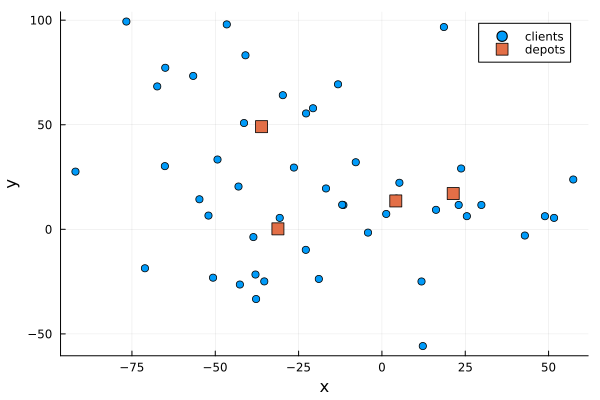

In [423]:
scatter(
    instance.positions[:,1], instance.positions[:,2],
    label = "clients",
    xlabel = "x",
    ylabel = "y",
    marker = (:circle, 4),
    legend = :topright
)

scatter!(
    instance.depots[:,2], instance.depots[:,3],
    label = "depots",
    marker = (:square, 6)
)

In [424]:
# =========================================
# Distancia euclidiana entre dos puntos
# p1 = [x1, y1], p2 = [x2, y2]
# =========================================
function euclidean_distance(p1::AbstractVector, p2::AbstractVector)
    return sqrt((p1[1] - p2[1])^2 + (p1[2] - p2[2])^2)
end

euclidean_distance (generic function with 1 method)

# Clustering


In [425]:
# =========================================
# Clusterización greedy por depósito más cercano
# con restricción de capacidad total por depósito
#
# depots:      matriz [depot_index  x  y]
# positions:   matriz [client_index => x y]
# weights:     vector de pesos de clientes
# capacity:    vector con capacidad por camión para cada depósito
# truck_num:   número de camiones por depósito
# =========================================
function clusterize_clients_to_depots(
    depots::Matrix{<:Real},
    positions::Matrix{<:Real},
    weights::Vector{<:Real},
    capacity::Vector{<:Real},
    truck_num::Int
)
    client_num = size(positions, 1)
    depot_num  = size(depots, 1)

    @assert size(depots, 2) == 3 "depots debe tener formato [depot_index x y]"
    @assert size(positions, 2) == 2 "positions debe tener formato [x y]"
    @assert length(weights) == client_num "weights debe tener longitud client_num"
    @assert length(capacity) == depot_num "capacity debe tener longitud depot_num"

    # =========================================
    # 1) Construir matriz clients = [index x y weight]
    # =========================================
    clients = Matrix{Float64}(undef, client_num, 4)
    for i in 1:client_num
        clients[i, 1] = i
        clients[i, 2] = positions[i, 1]
        clients[i, 3] = positions[i, 2]
        clients[i, 4] = weights[i]
    end

    # =========================================
    # 2) Ordenar clients de mayor a menor weight
    # =========================================
    sorted_idx = sortperm(clients[:, 4], rev = true)
    clients_sorted = clients[sorted_idx, :]

    # =========================================
    # 3) Crear matriz depot_capacity = [depot_index total_capacity]
    #    total_capacity = capacity[i] * truck_num
    # =========================================
    depot_capacity = Matrix{Float64}(undef, depot_num, 2)
    for j in 1:depot_num
        depot_capacity[j, 1] = depots[j, 1]
        depot_capacity[j, 2] = capacity[j] * truck_num
    end

    # Capacidades restantes
    remaining_capacity = copy(depot_capacity[:, 2])

    # =========================================
    # 4) Crear n diccionarios, uno por depósito
    #    Cada diccionario guarda:
    #    ("depot_index" => ..., "route" => [...])
    # =========================================
    depot_routes = [
        Dict(
            "depot_index" => Int(depots[j, 1]),
            "route" => Int[]
        )
        for j in 1:depot_num
    ]

    # Mapa depot_index -> fila en depots
    depot_id_to_row = Dict(Int(depots[j, 1]) => j for j in 1:depot_num)

    # =========================================
    # 5) Matriz global de distancias
    #    dist_node_depots = [node_index depot_index distance]
    #    Tendrá client_num * depot_num filas
    # =========================================
    dist_node_depots = Matrix{Float64}(undef, client_num * depot_num, 3)

    # También guardaremos la versión ordenada por cliente
    dist_node_depots_sorted = Vector{Matrix{Float64}}(undef, client_num)

    # Clientes no asignados
    unassigned_clients = Int[]

    # =========================================
    # 6) Clusterizacion
    # =========================================
    global_row = 1

    for r in 1:client_num
        client_index = Int(clients_sorted[r, 1])
        client_xy = clients_sorted[r, 2:3]
        client_weight = clients_sorted[r, 4]

        # Matriz local para este cliente:
        # [node_index depot_index distance]
        current_dist = Matrix{Float64}(undef, depot_num, 3)

        for j in 1:depot_num
            depot_index = Int(depots[j, 1])
            depot_xy = depots[j, 2:3]

            d = euclidean_distance(client_xy, depot_xy)

            current_dist[j, 1] = client_index
            current_dist[j, 2] = depot_index
            current_dist[j, 3] = d

            dist_node_depots[global_row, 1] = client_index
            dist_node_depots[global_row, 2] = depot_index
            dist_node_depots[global_row, 3] = d
            global_row += 1
        end

        # Ordenar de menor a mayor distancia
        order = sortperm(current_dist[:, 3])
        current_dist = current_dist[order, :]

        # Guardar versión ordenada de este cliente
        dist_node_depots_sorted[r] = current_dist

        # Intentar asignar al depósito factible más cercano
        assigned = false

        for k in 1:depot_num
            depot_index = Int(current_dist[k, 2])
            depot_row = depot_id_to_row[depot_index]

            if client_weight <= remaining_capacity[depot_row]
                push!(depot_routes[depot_row]["route"], client_index)
                remaining_capacity[depot_row] -= client_weight
                assigned = true
                break
            end
        end

        if !assigned
            push!(unassigned_clients, client_index)
        end
    end

    return (
        clients = clients,
        depot_routes = depot_routes,
        unassigned_clients = unassigned_clients
    )
end

clusterize_clients_to_depots (generic function with 1 method)

In [426]:
t1 = @elapsed cluster = clusterize_clients_to_depots(depots, positions, weights, capacity, truck_num)

0.673851408

In [427]:
clusters = cluster.depot_routes
unassigned_clients = cluster.unassigned_clients

Int64[]

In [428]:
function plot_clusters(
    depots::Matrix{<:Real},          # [depot_index x y]
    positions::Matrix{<:Real},       # [client_index x y]
    clusters,                    # vector de diccionarios
    unassigned_clients::Vector{Int}  # clientes no asignados
)
    # depot_index -> fila dentro de depots
    depot_id_to_row = Dict(Int(depots[j, 1]) => j for j in 1:size(depots, 1))

    p = plot(
        xlabel = "x",
        ylabel = "y",
        title = "Clusters by depot",
        legend = :outertopright,
        aspect_ratio = :equal,
        size = (800, 600)
    )

    # =========================
    # Graficar clientes asignados por depot
    # =========================
    for d in clusters
        depot_index = d["depot_index"]
        route = d["route"]

        if !isempty(route)
            scatter!(
                p,
                positions[route, 1],
                positions[route, 2],
                label = "clients depot $depot_index",
                markersize = 4
            )
        end
    end

    # =========================
    # Graficar clientes no asignados
    # =========================
    if !isempty(unassigned_clients)
        scatter!(
            p,
            positions[unassigned_clients, 1],
            positions[unassigned_clients, 2],
            label = "unassigned",
            markershape = :x,
            markersize = 4
        )
    end

    # =========================
    # Graficar depots
    # =========================
    scatter!(
        p,
        depots[:, 2],
        depots[:, 3],
        label = "depots",
        markershape = :square,
        markersize = 6
    )


    return p
end

plot_clusters (generic function with 1 method)

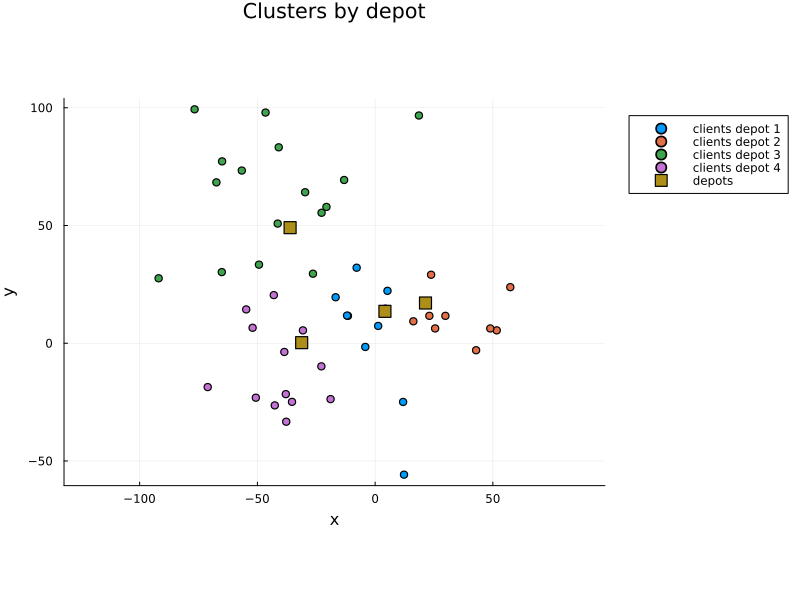

In [429]:
plot_clusters(
    depots,
    positions,
    clusters,
    unassigned_clients
)

# Routing the clusters

In [430]:
# =========================================
# Heurística greedy de ruteo por depósito
#
# depots: matriz [depot_index x y]
# positions: matriz [client_index => x y]
# weights: vector de pesos por cliente
# clusters: resultado de la clusterización
#              cada elemento tiene:
#              Dict("depot_index" => ..., "route" => [clientes del cluster])
# capacity: vector de capacidad por camión para cada depósito
# truck_num: número de camiones por depósito
# =========================================
function greedy_routing_by_depot(
    depots::Matrix{<:Real},
    positions::Matrix{<:Real},
    weights::Vector{<:Real},
    clusters,
    capacity::Vector{<:Real},
    truck_num::Int
)
    depot_num = size(depots, 1)

    @assert size(depots, 2) == 3 "depots debe tener formato [depot_index x y]"
    @assert size(positions, 2) == 2 "positions debe tener formato [x y]"
    @assert length(weights) == size(positions, 1) "weights y positions no coinciden"
    @assert length(capacity) == depot_num "capacity debe tener una entrada por depósito"

    # Mapa depot_index -> fila en depots
    depot_id_to_row = Dict(Int(depots[j, 1]) => j for j in 1:depot_num)

    routing_solution = Vector{Dict}(undef, length(clusters))
    global_unrouted = Int[]

    for d in 1:length(clusters)
        depot_index = clusters[d]["depot_index"]
        cluster_clients = copy(clusters[d]["route"])

        depot_row = depot_id_to_row[depot_index]
        depot_xy = depots[depot_row, 2:3]

        # Crear estructura de camiones para este depósito
        trucks = [
            Dict(
                "truck_id" => k,
                "route" => Int[],
                "load" => 0.0,
                "remaining_capacity" => float(capacity[depot_row]),
                "distance" => 0.0
            )
            for k in 1:truck_num
        ]

        # ==================================================
        # Llenar los camiones greedy
        # ==================================================
        for k in 1:truck_num
            current_pos = depot_xy

            while true
                # Clientes aún no atendidos que caben en el camión
                feasible_clients = [
                    c for c in cluster_clients
                    if weights[c] <= trucks[k]["remaining_capacity"]
                ]

                if isempty(feasible_clients)
                    break
                end

                # Elegir el cliente factible más cercano a la posición actual
                distances = [
                    euclidean_distance(current_pos, positions[c, :])
                    for c in feasible_clients
                ]

                best_pos = argmin(distances)
                best_client = feasible_clients[best_pos]
                best_distance = distances[best_pos]

                # Actualizar camión
                push!(trucks[k]["route"], best_client)
                trucks[k]["load"] += weights[best_client]
                trucks[k]["remaining_capacity"] -= weights[best_client]
                trucks[k]["distance"] += best_distance

                # La nueva posición actual es el cliente recién agregado
                current_pos = positions[best_client, :]

                # Quitar cliente de la lista pendiente del depósito
                deleteat!(cluster_clients, findfirst(==(best_client), cluster_clients))
            end

            # Regreso al depósito si el camión visitó al menos un cliente
            if !isempty(trucks[k]["route"])
                trucks[k]["distance"] += euclidean_distance(current_pos, depot_xy)
            end
        end

        # Clientes que no pudieron rutearse en este depósito
        unrouted_here = copy(cluster_clients)
        append!(global_unrouted, unrouted_here)

        routing_solution[d] = Dict(
            "depot_index" => depot_index,
            "trucks" => trucks,
            "unrouted_clients" => unrouted_here,
            "total_distance" => sum(t["distance"] for t in trucks)
        )
    end

    return Dict(
        "routing_solution" => routing_solution,
        "global_unrouted" => global_unrouted
    )
end

greedy_routing_by_depot (generic function with 1 method)

In [431]:
t2 = @elapsed routing_result = greedy_routing_by_depot(
    depots,
    positions,
    weights,
    clusters,
    capacity,
    truck_num
)

0.572936261

# We observe the total route distance per depot and for the hole instance

In [432]:
for d in routing_result["routing_solution"]
    println("Depot ", d["depot_index"], " -> total_distance = ", d["total_distance"])
end

Depot 1 -> total_distance = 235.7655377649303
Depot 2 -> total_distance = 169.51465624636378
Depot 3 -> total_distance = 556.5763345188201
Depot 4 -> total_distance = 198.3183764835196


In [433]:
total_distance_global = sum(d["total_distance"] for d in routing_result["routing_solution"])

1160.1749050136336

# We visualize the end result

In [434]:
function plot_mdvrp_solution(
    depots::Matrix{<:Real},
    positions::Matrix{<:Real},
    clusters,
    routing_result;
    unassigned_clients = Int[]
)

    depot_num = size(depots, 1)

    # Mapa depot_index -> fila en depots
    depot_id_to_row = Dict(Int(depots[j, 1]) => j for j in 1:depot_num)

    # Paleta de colores, uno por depot
    colors = palette(:tab10, depot_num)

    p = plot(
        xlabel = "x",
        ylabel = "y",
        title = "MDVRP Clusters and Routes",
        legend = :outertopright,
        aspect_ratio = :equal,
        size = (800, 800)
    )

    # =========================================
    # 1) Graficar todos los nodos
    # =========================================
    scatter!(
        p,
        positions[:, 1],
        positions[:, 2],
        label = "all clients",
        markersize = 4,
        markerstrokewidth = 0,
        alpha = 0.35,
        color = :gray
    )

    # =========================================
    # 2) Graficar clusters por depot
    # =========================================
    for (j, d) in enumerate(clusters)
        depot_index = d["depot_index"]
        cluster = d["route"]

        if !isempty(cluster)
            scatter!(
                p,
                positions[cluster, 1],
                positions[cluster, 2],
                label = "cluster $depot_index",
                markersize = 4,
                color = colors[j]
            )
        end
    end

    # =========================================
    # 3) Graficar rutas
    # =========================================
    for depot_sol in routing_result["routing_solution"]
        depot_index = depot_sol["depot_index"]
        depot_row = depot_id_to_row[depot_index]

        dx = depots[depot_row, 2]
        dy = depots[depot_row, 3]

        color_idx = depot_row

        for truck in depot_sol["trucks"]
            route = truck["route"]

            if !isempty(route)
                xs = vcat(dx, positions[route, 1], dx)
                ys = vcat(dy, positions[route, 2], dy)

                plot!(
                    p,
                    xs,
                    ys,
                    label = false,
                    linewidth = 2,
                    alpha = 0.9,
                    color = colors[color_idx]
                )
            end
        end
    end

    # =========================================
    # 4) Graficar clientes no asignados / no ruteados
    # =========================================
    if isempty(unassigned_clients)
        if haskey(routing_result, "global_unrouted")
            unassigned_clients = routing_result["global_unrouted"]
        end
    end

    if !isempty(unassigned_clients)
        scatter!(
            p,
            positions[unassigned_clients, 1],
            positions[unassigned_clients, 2],
            label = "unassigned",
            markershape = :x,
            markersize = 4,
            color = :black
        )
    end

    # =========================================
    # 5) Graficar depots
    # =========================================
    scatter!(
        p,
        depots[:, 2],
        depots[:, 3],
        label = "depots",
        markershape = :square,
        markersize = 6,
        color = :red
    )

    return p
end

plot_mdvrp_solution (generic function with 1 method)

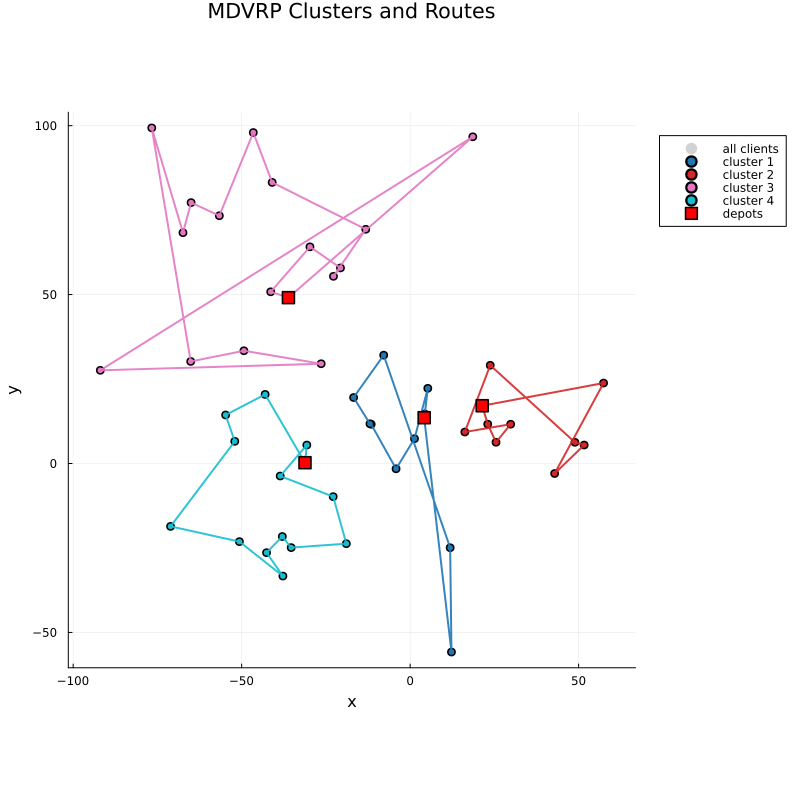

In [435]:
plot_mdvrp_solution(
    depots,
    positions,
    clusters,
    routing_result
)

# We calculate the total time the program takes to make the routes
(Doesnt consider the plots time)

---



In [436]:
total_time = t1+t2

1.246787669

# Finally we show the total route length and computational time for each instance

In [437]:
println("Total route lenght: ", total_distance_global)
println("Computation time: ", total_time)

Total route lenght: 1160.1749050136336
Computation time: 1.246787669


# Now withe the framework laid before, we iterate for every instance to see the results

In [438]:
using DataFrames, CSV

In [439]:
function run_cluster_greedy_experiments(folder_path::String, n::Int)
    # =========================
    # 1) Leer archivos y tomar las primeras n instancias
    # =========================
    files = sort(readdir(folder_path))
    files = files[1:min(n, length(files))]

    # =========================
    # 2) Crear dataframe vacío
    # =========================
    results_df = DataFrame(
        "instance" => String[],
        "Cluster+Greedy (length)" => Float64[],
        "Cluster+Greedy (time)" => Float64[]
    )

    # =========================
    # 3) Iterar por cada instancia
    # =========================
    for file in files
        filepath = joinpath(folder_path, file)

        # Leer instancia
        instance = read_mdvrp_instance(filepath)

        truck_num = instance.truck_num
        capacity = instance.capacities
        weights = instance.weights
        positions = instance.positions

        # Si tu lector devuelve instance.depots, usa esta línea:
        depots = instance.depots

        # Si tu lector devuelve instance.depot_positions en vez de instance.depots,
        # usa esto en lugar de la línea anterior:
        # depots = hcat(collect(1:size(instance.depot_positions,1)), instance.depot_positions)

        # =========================
        # Clusters
        # =========================
        t1 = @elapsed cluster = clusterize_clients_to_depots(
            depots,
            positions,
            weights,
            capacity,
            truck_num
        )

        clusters = cluster.depot_routes
        unassigned_clients = cluster.unassigned_clients

        # =========================
        # Ruteo
        # =========================
        t2 = @elapsed routing_result = greedy_routing_by_depot(
            depots,
            positions,
            weights,
            clusters,
            capacity,
            truck_num
        )

        # =========================
        # Distancia total
        # =========================
        total_distance_global = sum(
            d["total_distance"] for d in routing_result["routing_solution"]
        )

        # Tiempo total
        total_time = t1 + t2

        # =========================
        # Guardar fila en dataframe
        # =========================
        push!(results_df, (
            file,
            total_distance_global,
            total_time
        ))
    end

    return results_df
end

run_cluster_greedy_experiments (generic function with 1 method)

In [440]:
results_df = run_cluster_greedy_experiments("/content/instances", typemax(Int))
display(results_df)

Row,instance,Cluster+Greedy (length),Cluster+Greedy (time)
,String,Float64,Float64
1,p01,769.18,0.0122065
2,p02,662.861,0.00086584
3,p03,929.006,0.000668134
4,p04,1310.06,0.000958207
5,p05,1187.78,0.000924129
6,p06,1356.86,0.000924981
7,p07,1303.35,0.000785819
8,p08,6903.87,0.00405948
9,p09,6364.97,0.00319512


In [441]:
CSV.write("/content/cluster_greedy_results.csv", results_df)

"/content/cluster_greedy_results.csv"

In [442]:
using Pkg
Pkg.add("PyCall")   # no siempre funciona, se puede descargar el csv de forma manual
using PyCall

files = pyimport("google.colab.files")
files.download("/content/cluster_greedy_results.csv")

   Resolving package versions...
  No Changes to `~/.julia/environments/v1.11/Project.toml`
  No Changes to `~/.julia/environments/v1.11/Manifest.toml`


LoadError: PyError ($(Expr(:escape, :(ccall(#= /root/.julia/packages/PyCall/1gn3u/src/pyfncall.jl:43 =# @pysym(:PyObject_Call), PyPtr, (PyPtr, PyPtr, PyPtr), o, pyargsptr, kw))))) <class 'AttributeError'>
AttributeError("'NoneType' object has no attribute 'kernel'")
  File "/usr/local/lib/python3.12/dist-packages/google/colab/files.py", line 232, in download
    comm_manager = _IPython.get_ipython().kernel.comm_manager
                   ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
